In [57]:
import os
import numpy as np
import matplotlib.pyplot as plt
import math

from scipy.interpolate import CubicSpline
from pyampd.ampd import find_peaks

In [ ]:
folder = r"0_subject"     

signals = {}
lengths = []

for file in sorted(os.listdir(folder)):
    if file.endswith(".txt"):
        path = os.path.join(folder, file)

        signal = np.loadtxt(path)

        signals[file] = signal
        lengths.append(len(signal))

print("Total signals:", len(signals))
print("First file:", list(signals.keys())[0])
print("Length:", lengths[0])



Total signals: 657
First file: 100_1.txt
Length: 2100


In [59]:
signals["100_1.txt"]

array([1994., 1992., 1992., ..., 2119., 2085., 2085.])

In [60]:
signals["100_1.txt"].shape

(2100,)

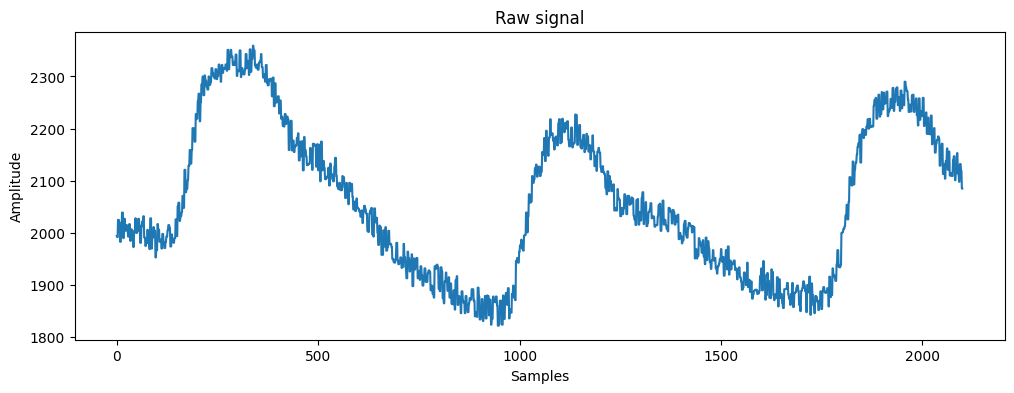

In [61]:
file = list(signals.keys())[0]

plt.figure(figsize=(12,4))
plt.plot(signals[file])
plt.title("Raw signal")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

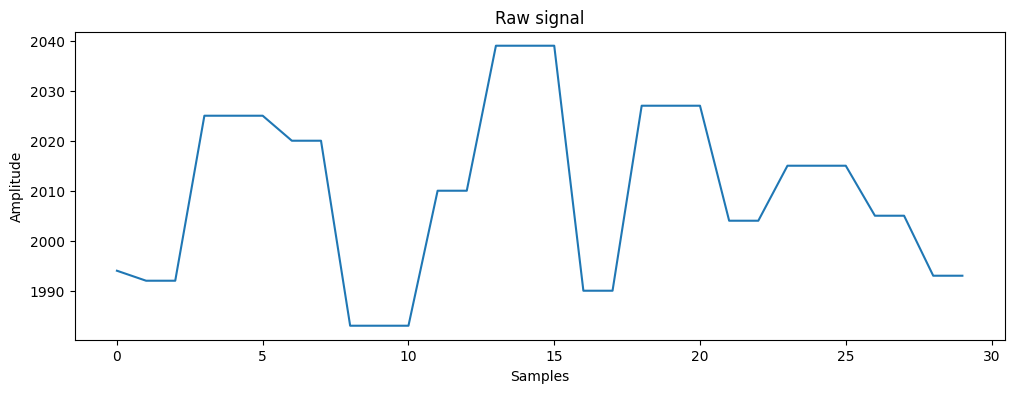

In [62]:
plt.figure(figsize=(12,4))
plt.plot(signals[file][:30])
plt.title("Raw signal")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

## Downsampling ##

We'll downsample it from 1000 to 125 Hz

262


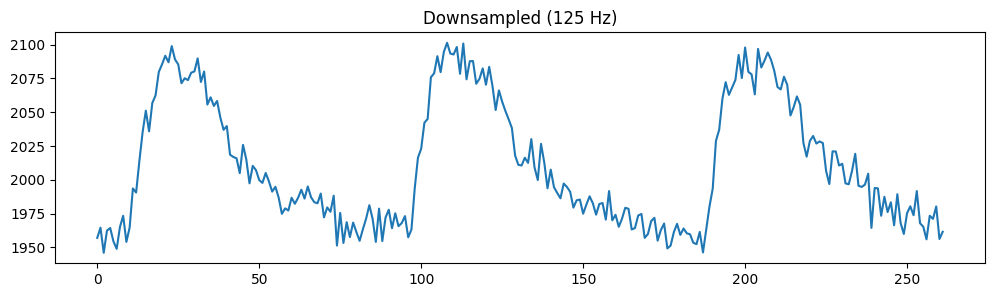

In [91]:
from scipy.signal import resample

fs_original = 1000
fs_new = 125

num_samples = int(len(signal) * fs_new / fs_original)
print(num_samples)

signal_ds = resample(signal, num_samples)

plt.figure(figsize=(12,3))
plt.plot(signal_ds)
plt.title("Downsampled (125 Hz)")
plt.show()

## BANDPASS FILTER ##

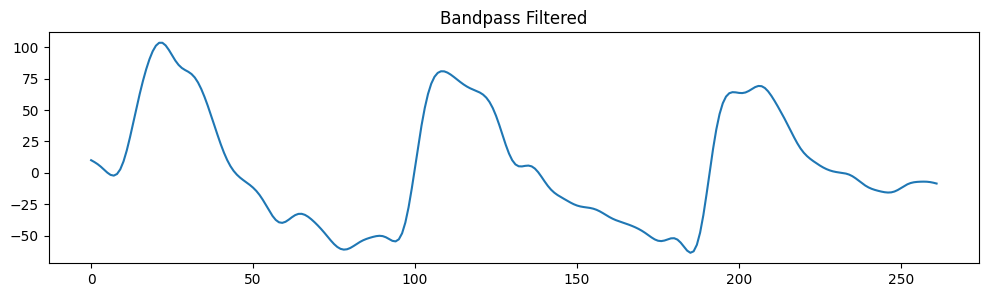

In [92]:
from scipy.signal import butter, filtfilt

lowcut = 0.7
highcut = 12

nyquist = fs_new / 2

b, a = butter(
    N=4,
    Wn=[lowcut/nyquist, highcut/nyquist],
    btype='band'
)

signal_filtered = filtfilt(b, a, signal_ds)

plt.figure(figsize=(12,3))
plt.plot(signal_filtered)
plt.title("Bandpass Filtered")
plt.show()

In [100]:
# DETECT PEAKS
fs = 125
pks = find_peaks(signal_filtered, fs)

# remove peaks at boundaries
if len(pks) > 0:
    if pks[0] == 0:
        pks = pks[1:]
    if pks[-1] == len(signal_filtered)-1:
        pks = pks[:-1]

In [101]:
# DETECT VALLEYS
vlys = find_peaks(-signal_filtered, fs)

if len(vlys) > 0:
    if vlys[0] == 0:
        vlys = vlys[1:]
    if vlys[-1] == len(signal_filtered)-1:
        vlys = vlys[:-1]

In [102]:
rollingmin_idx = vlys
rollingmin = signal_filtered[vlys]

mean = np.mean(rollingmin)

dist = np.median(np.diff(rollingmin_idx))
med = np.median(rollingmin)

# ---------- head ----------
add_pts_head = math.ceil(rollingmin_idx[0] / dist)

head_d = [
    rollingmin_idx[0] - i*dist
    for i in reversed(range(1, add_pts_head+1))
]

head_m = [med] * add_pts_head

# ---------- tail ----------
add_pts_tail = math.ceil((len(signal_filtered)-rollingmin_idx[-1]) / dist)

tail_d = [
    rollingmin_idx[-1] + i*dist
    for i in range(1, add_pts_tail+1)
]

tail_m = [med] * add_pts_tail

rollingmin_idx = np.concatenate(
    (head_d, rollingmin_idx, tail_d)
)

rollingmin = np.concatenate(
    (head_m, rollingmin, tail_m)
)

In [103]:
cs = CubicSpline(
    rollingmin_idx,
    rollingmin
)

baseline = cs(np.arange(len(signal_filtered)))
signal_corrected = signal_filtered - (baseline - mean)

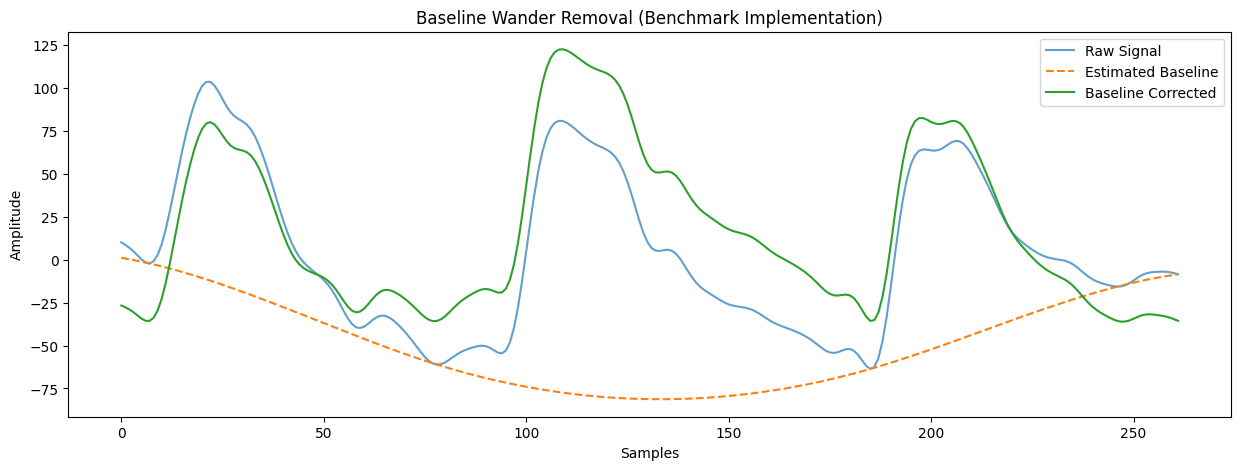

In [104]:
plt.figure(figsize=(15,5))

plt.plot(signal_filtered, label='Raw Signal', alpha=0.7)
plt.plot(baseline, '--', label='Estimated Baseline')
plt.plot(signal_corrected, label='Baseline Corrected')

plt.legend()
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.title("Baseline Wander Removal (Benchmark Implementation)")

plt.show()